# Detecção de fraudes em transações

**Professora:** Dra. Isadora Garcia Ferrão

In [1]:
print("Hello, World!")

Hello, World!


In [ ]:
#import requests

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [3]:

## Para carregar os dados a partir da URL, caso queira usar o dataset localmente, basta comentar as
# linhas abaixo e descomentar a linha de leitura do CSV local
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

# Leitura a partir da URL
df = pd.read_csv(url)
df.head()

# Leitura a partir do arquivo creditcard.csv local
# response = requests.get(url)
# with open("data/creditcard.csv", "wb") as f:
#     f.write(response.content)
# df = pd.read_csv("data/creditcard.csv")
# df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Problema de classificação desbalanceada

Fraudes são raras $\rightarrow$ modelo pode ignorar a classe 1

In [7]:
df.Class.value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## Feature Engineering

Criamos variáveis que ajudam o modelo

In [8]:
df['Amount_log'] = np.log1p(df['Amount'])

In [9]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Amount_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,1.124303
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-1.114639
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,1.682368
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,1.009339
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.670241


In [10]:
X = df.drop("Class",axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression

In [11]:
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

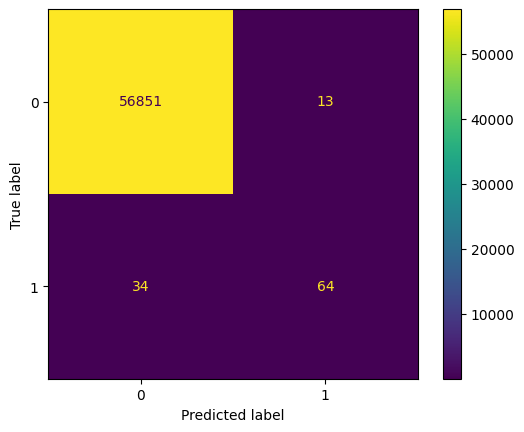

In [12]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Acurácia pode ser alta mesmo sem detectar fraudes. Por isso devemos usar:
- Recall (mais importante, pq?)
- Precision
- F1-Score

### Recall

O *recall* é uma métrica que mede...


### Precision

*Precision* é uma métrica que mede ...


### F1-Score

*F1-score* é uma métrica que mede...

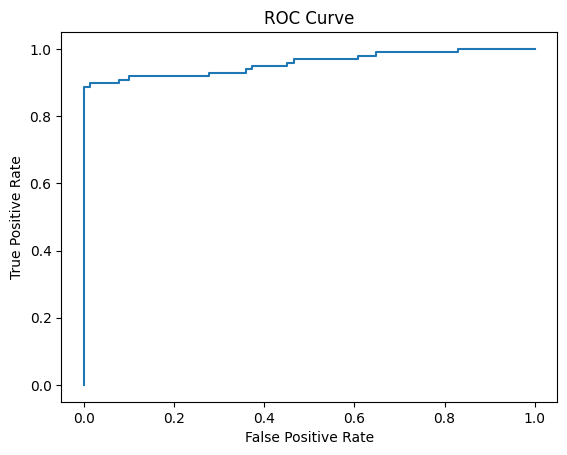

AUC 0.9568542702674767


In [14]:
y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr,_ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC", roc_auc_score(y_test, y_probs))

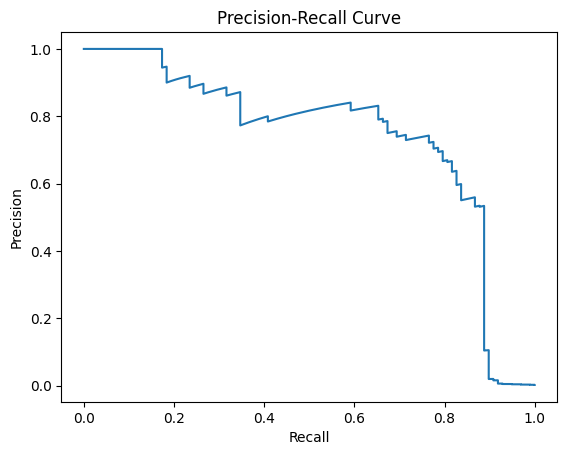

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

O que significa a curva precision-recall? COmo interpretar?

## Balanceamento de dados

In [16]:
# Undersampling
fraudes = df[df.Class == 1]
normais = df[df.Class == 0].sample(n=len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [17]:
# Oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

## Outros modelos

- O que são modelos de Boosting e bagging?

In [18]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.59      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.80      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
xgb = XGBClassifier(
    scale_pos_weight=10,  # Ajuste para lidar com o desbalanceamento
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)



c:\Users\marcio_constancio\Documents\Projeto Marcio\deteccao-fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:45:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Pipeline 

In [21]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
threshold = 0.3

y_pred_custom = (y_probs >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## Importância das variáveis

Ajuda a entender quais variáveis influenciam mais o modelo

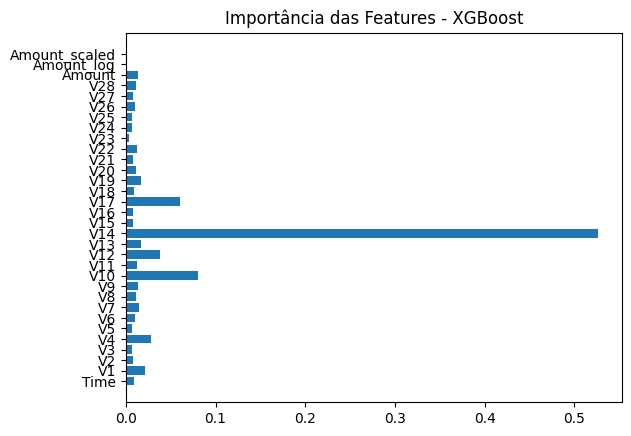

In [22]:
importancias = xgb.feature_importances_

plt.barh(X.columns, importancias)
plt.title("Importância das Features - XGBoost")
plt.show()

## Ajuste de hiperparâmetros

Testamos várias combinações para melhorar o modelo

In [ ]:
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100]
}

grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    scoring='recall',
    cv = 3,
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'max_depth': 5, 'n_estimators': 100}


## Explicabildiade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo.

In [24]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])
shap.plots.bar(shap_values)

NameError: name 'shap' is not defined